In [1]:
!pip install -q kaggle

In [2]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d datamunge/sign-language-mnist

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
100% 62.6M/62.6M [00:00<00:00, 81.1MB/s]



In [5]:
!unzip -q sign-language-mnist.zip

**Imports**

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns

In [7]:
train_df=pd.read_csv('sign_mnist_train.csv')
test_df=pd.read_csv('sign_mnist_test.csv')

In [8]:
X_train = train_df.drop('label',axis=1).values
y_train = train_df['label'].values

In [9]:
X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

In [10]:
X_train=X_train.astype('float32')/255.0
X_test=X_test.astype('float32')/255.0

In [11]:
X_train=X_train.reshape(-1,28,28,1)
X_test=X_test.reshape(-1,28,28,1)

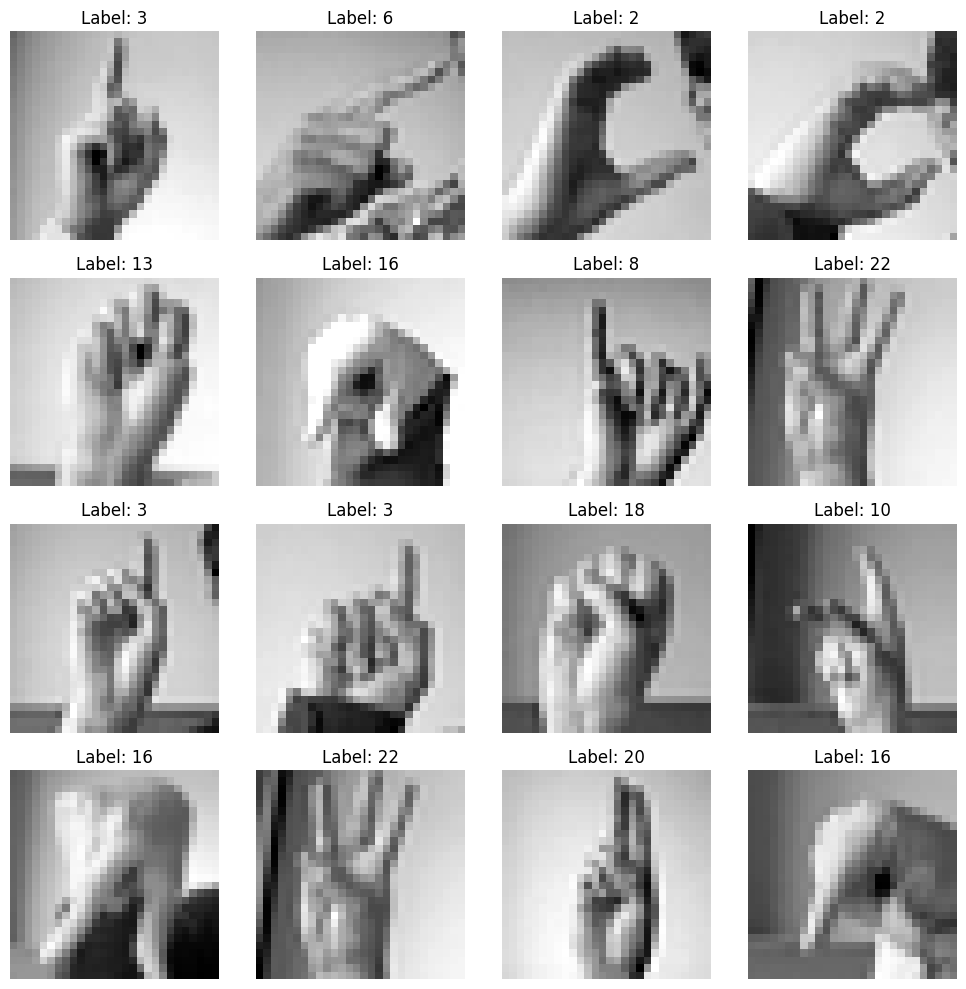

In [12]:
plt.figure(figsize=(10,10))
for i in range(16):
  plt.subplot(4,4,i+1)
  plt.imshow(X_train[i].squeeze(),cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")
plt.tight_layout()
plt.show()

**index to alphabet**

In [13]:
unique_labels=sorted(np.unique(y_train))

label_to_index={
    label:index
    for index,label in enumerate(unique_labels)
}

index_to_label = {
    index:label
    for label,index in label_to_index.items()
}

In [14]:
y_train_encoded = np.array([label_to_index[label] for label in y_train])
y_test_encoded = np.array([label_to_index[label] for label in y_test])

In [15]:
letters = [
    'A','B','C','D','E','F','G','H',
    'I','K','L','M','N','O','P','Q','R','S','T','U','V','W','X','Y'
]

**train_test_split**

In [16]:
X_train,X_val,y_train,y_val = train_test_split(
    X_train,
    y_train_encoded,
    test_size=0.1,
    random_state=42,
    stratify=y_train_encoded
)

In [18]:
X_train=tf.image.resize(X_train,(224,224))
X_test=tf.image.resize(X_test,(224,224))
X_val=tf.image.resize(X_val,(224,224))

In [ ]:
preprocess=

**Model**

In [32]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [33]:
from tensorflow.keras import layers
model = Sequential()

model.add(tf.keras.layers.Input(shape=(28,28,1)))

model.add(tf.keras.layers.Resizing(224,224))

model.add(tf.keras.layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)))

model.add(base_model)

model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dense(128,activation="relu"))

model.add(tf.keras.layers.Dropout(0.3))

model.add(tf.keras.layers.Dense(24,activation="softmax"))

In [34]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,048 (9.25 MB)

 Trainable params: 167,064 (652.59 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [35]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Training**

In [36]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val,y_val)
)

Epoch 1/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 46s 47ms/step - accuracy: 0.8853 - loss: 0.4203 - val_accuracy: 0.9956 - val_loss: 0.0370
Epoch 2/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9900 - loss: 0.0499 - val_accuracy: 0.9985 - val_loss: 0.0095
Epoch 3/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9936 - loss: 0.0287 - val_accuracy: 1.0000 - val_loss: 0.0069
Epoch 4/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9957 - loss: 0.0189 - val_accuracy: 1.0000 - val_loss: 0.0029
Epoch 5/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9944 - loss: 0.0204 - val_accuracy: 0.9996 - val_loss: 0.0027
Epoch 6/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9958 - loss: 0.0150 - val_accuracy: 0.9978 - val_loss: 0.0075
Epoch 7/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9962 - loss: 0.0126 - val_accuracy: 0.9985 - val_loss: 0.0060
Epoch 8/10
773/773 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9946 - loss: 0.0180 - 

**Plotting**

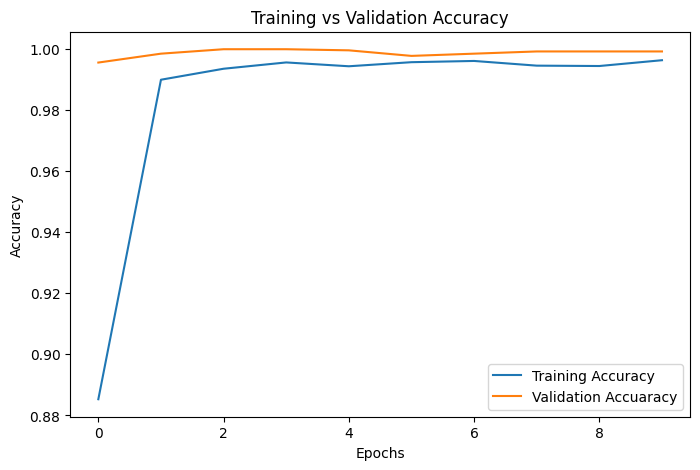

In [37]:
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuaracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.show()

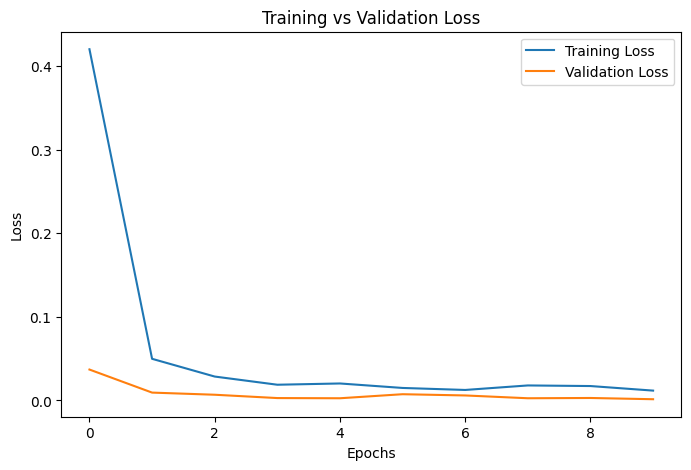

In [38]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'],label="Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.show()

**Predictions**

In [39]:
predictions=model.predict(X_test)
predicted_classes=np.argmax(predictions,axis=1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 28s 105ms/step


**Classification** **Report**

In [40]:
print(classification_report(
    y_test_encoded,
    predicted_classes,
    target_names=letters
  )
)

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      0.96      0.98       310
           D       0.95      1.00      0.98       245
           E       1.00      0.97      0.98       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      0.96      0.98       331
           L       1.00      1.00      1.00       209
           M       0.96      1.00      0.98       394
           N       1.00      1.00      1.00       291
           O       0.96      1.00      0.98       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       0.99      1.00      1.00       144
           S       1.00    

In [52]:
model.input_shape

(None, 28, 28, 1)

**Testing** **a** **new** **image**

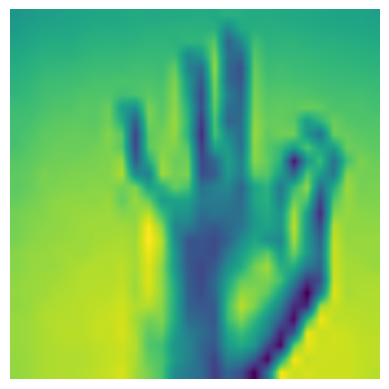

Predicted: F
Actual: F


In [54]:


index = 1

image = X_test[index]
plt.imshow(image)
plt.axis("off")
plt.show()

image = tf.expand_dims(image, 0)   # (1,28,28,1)

prediction = model.predict(image, verbose=0)

predicted_index = np.argmax(prediction)

print("Predicted:", letters[predicted_index])
print("Actual:", letters[y_test_encoded[index]])

**Saving** **the** **model**

In [55]:
model.save('sign_language_cnn_MobileNetV2.keras')

In [56]:
from google.colab import files
files.download(
    'sign_language_cnn_MobileNetV2.keras'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>